In [25]:
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

url=r'c:\Windows\Fonts\NanumBarunGothic.ttf'
fm.fontManager.addfont(url)
plt.rc('font', family = fm.FontProperties(fname=url).get_name())


fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8, 
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7, 
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

fish_data = np.column_stack((fish_length, fish_weight))
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target= \
    train_test_split(fish_data, fish_target, random_state=42, stratify=fish_target)

from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

kn.predict([[25, 150]])

array([0.])

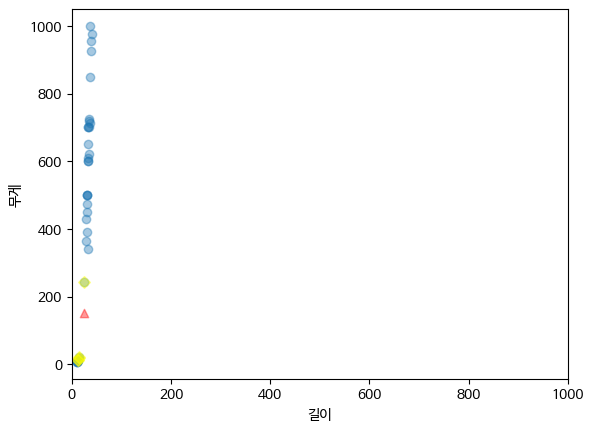

In [ ]:
distances, indexes = kn.kneighbors([[25, 150]])

plt.scatter(train_input[:, 0], train_input[:, 1], alpha=0.4)
plt.scatter(25, 150, alpha=0.4, c='red', marker='^')
plt.scatter(train_input[indexes, 0], train_input[indexes, 1], marker='D', c = 'yellow', alpha=0.4)
plt.xlabel('길이')
plt.xlim(0, 1000)
plt.ylabel('무게')
plt.show()


C:\Users\박중현\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


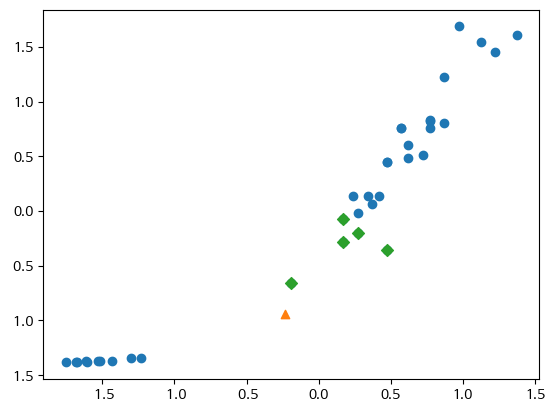

In [69]:
m = np.mean(train_input, axis=0)
s = np.std(train_input, axis=0)

train_scaled = ((train_input - m) / s)
test_scaled = (test_input-m) / s
a=([25, 150]-m)/s

kn.fit(train_scaled, train_target)
kn.score(test_scaled, test_target)
kn.predict([a])

distances, indexes = kn.kneighbors([a])

plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(a[0], a[1], marker='^')
plt.scatter(train_scaled[indexes, 0], train_scaled[indexes, 1], marker='D')
plt.show()
